# Introduction to Statistical Learning
## Chapter 3 exercises - Linear Regression

In [1]:
# Import standard libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [2]:
# We shall use the statsmodels package
import statsmodels.api as sm

# Import VIFs and anova
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm


The ISLP python package contains various datasets used in the book/exercises, as well as helper functions like `ModelSpec`, which we can use to create design matrix constructors.

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

#### Exercise 8: Auto data set

In [4]:
# Load the Auto data set
Auto = load_data("Auto")
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [5]:
# (a) Use sm.OLS to perform simple linear regression of mpg onto horsepower

design = MS(['horsepower'])
X = design.fit_transform(Auto)
y = Auto['mpg']

# Fit the model and print results
model = sm.OLS(y, X)
results = model.fit()

summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


i), ii) and iii) There is a clear relationship between the predictor and response variables `mpg` and `horsepower`. The p value corresponding to the t-test is essentially zero (as we see as last entry in the second row above), therefore there is strong evidence of a relationship between `mpg` and `horsepower`. The coefficent $\hat{\beta}_{\text{horsepower}}$ listed for horsepower is slightly negative, indicating a negative relationship between the two variables.

In [6]:
# (iv) Let's compute the predicted mpg associated with a horsepower of 98

prediction_values = pd.DataFrame({'horsepower':[98]})
X_pred = design.transform(prediction_values)
X_pred

predictions = results.get_prediction(X_pred);
predictions.predicted_mean

array([24.46707715])

In [7]:
# 95% confidence interval
CI = predictions.conf_int(alpha=0.05)
print('95% CI is {0}'.format(CI))

# 95% Prediction interval
PI = predictions.conf_int(obs=True, alpha=0.05)
print('95% prediction interval is {0}'.format(PI))

95% CI is [[23.97307896 24.96107534]]
95% prediction interval is [[14.80939607 34.12475823]]


<Axes: xlabel='horsepower', ylabel='mpg'>

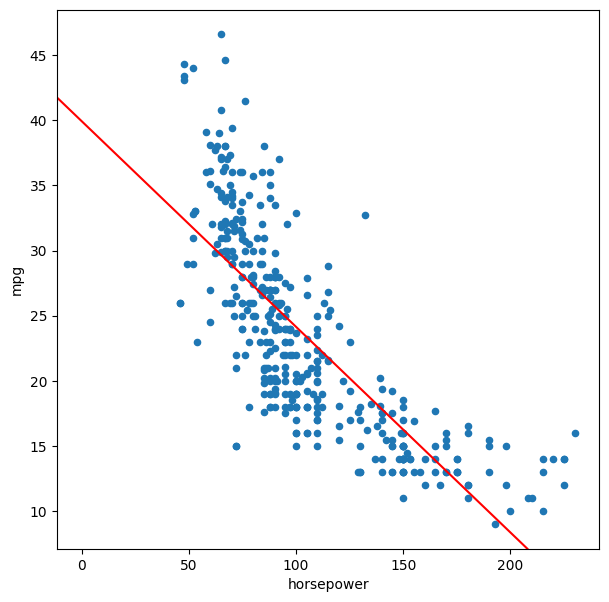

In [8]:
# (b) Plot the reponse and predictor with least squares regression line

intercept = results.params.iloc[0]
coeff_horsepower = results.params.iloc[1]

ax = subplots(figsize=(7,7))[1]
ax.axline((0, intercept), slope=coeff_horsepower, c="r")
Auto.plot.scatter('horsepower', 'mpg', ax=ax)


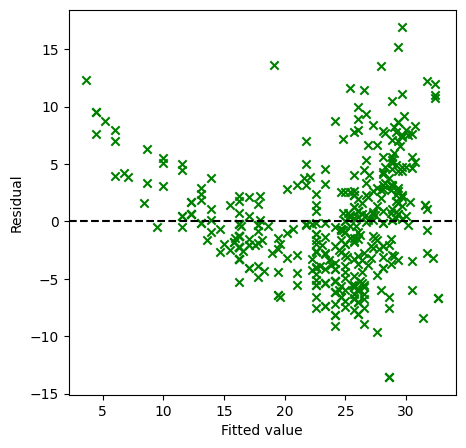

In [9]:
# (c) Now, let's plot the residuals against the fitted values

residuals = results.resid
fitted_values = results.fittedvalues

fig, ax = subplots(figsize=(5,5))
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.scatter(fitted_values, residuals, c="g", marker='x')
ax.axhline(0, c="black", ls="--")


The residual plot above suggests a non-linear pattern in the data, indicating that a simple linear model may be insufficient. This could potentially be addressed by including a quadratic term among the predictors.

#### Exercise 9: Auto data set - Multiple linear regression

In this question, we apply multiple linear regression to the `Auto` dataset from above.

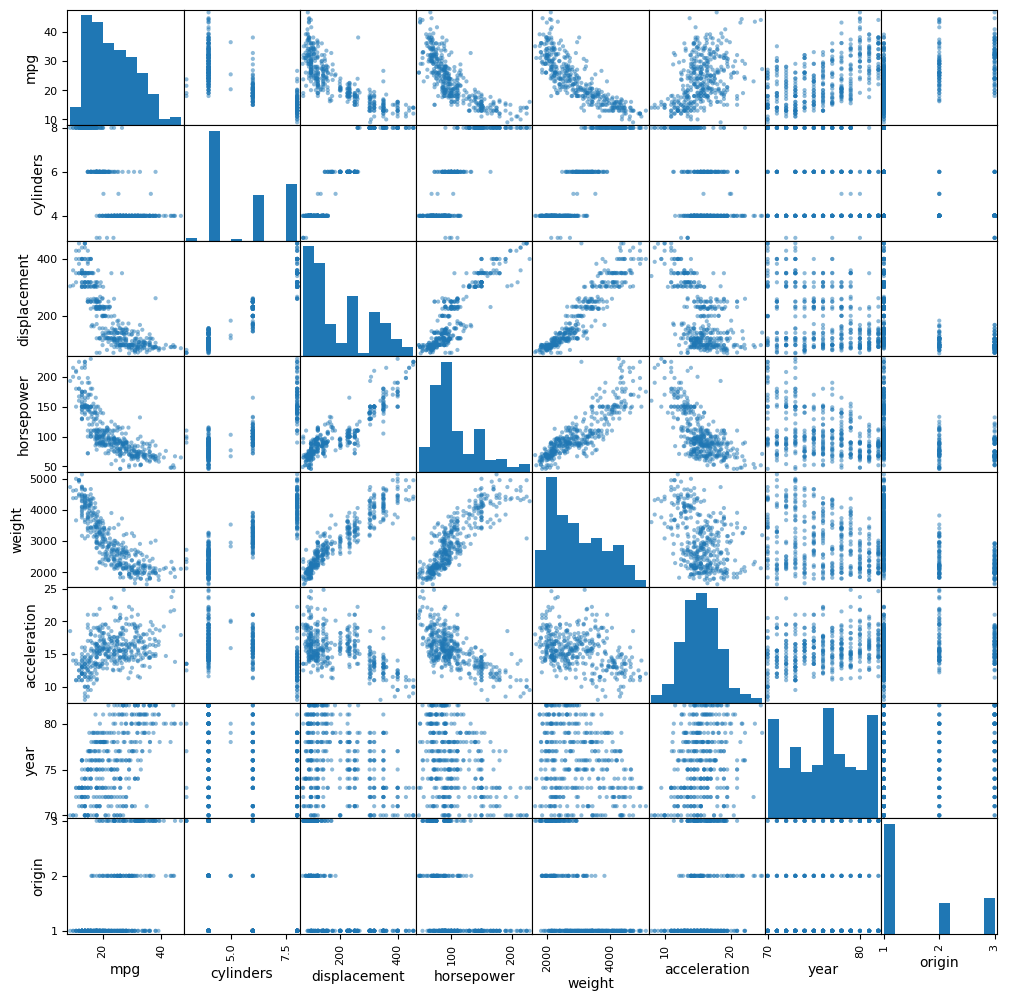

In [10]:
# (a) Produce a scatterplot matrix with all the variables
ax = pd.plotting.scatter_matrix(Auto, figsize=(12, 12))

In [11]:
# (b) Compute the matric of correlations
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [12]:
# (c) Perform multiple linear regression on all variables
all_vars = Auto.columns.drop('mpg')

design = MS(all_vars)
X = design.fit_transform(Auto)

model = sm.OLS(y, X)
results = model.fit()
summarize(results)


,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


We can get identical results using a formula to specify the model. (anova_lm does not work on the above code, see https://github.com/statsmodels/statsmodels/issues/8241)

In [13]:
import statsmodels.formula.api as smf

In [14]:
# (c) Perform multiple linear regression on all variables
all_vars = Auto.columns.drop('mpg')

formula = ' + '.join(all_vars)

model_auto2 = smf.ols(f'mpg ~ {formula}', data=Auto)
results2 = model_auto2.fit()

summarize(results2)

,coef,std err,t,P>|t|
Intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [15]:
# Use ANOVA to test whether the model explains a significant amount of variance
anova_lm(results2)

,df,sum_sq,mean_sq,F,PR(>F)
cylinders,1.0,14403.083079,14403.083079,1300.683788,2.319511e-125
displacement,1.0,1073.344025,1073.344025,96.929329,1.530906e-20
horsepower,1.0,403.408069,403.408069,36.430140,3.731128e-09
weight,1.0,975.724953,975.724953,88.113748,5.544461e-19
acceleration,1.0,0.966071,0.966071,0.087242,7.678728e-01
year,1.0,2419.120249,2419.120249,218.460900,1.875281e-39
origin,1.0,291.134494,291.134494,26.291171,4.665681e-07
Residual,384.0,4252.212530,11.073470,NaN,NaN
